## EE205 Artificial Intelligence I
# Part 10 - Linear regression
## Tutorial
### Barry Dillon

Here we'll load the Palmer Penguins dataset from the lecture.
We'll fit a linear regression model that predicts the weight of the penguins based on:
- just their flipper length
- their flipper length, bill length, and bill depth.

We'll then compare the performance of the two models in predicting the penguin weight.

What do you expect to happen?

1 - Import `pandas` (as pd), `numpy` (as np), `pyplot` (as plt), as well as the `LinearRegression` model, the `r2_score`, and the `mean_squared_error score`.

Note:  The mean_squared_error score calculates the mean of all the residuals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


2 - Load the penguins csv file as a DataFrame using pandas, and print the first 5 lines of the DataFrame.

In [2]:
df = pd.read_csv('C:/Users\Mariam\Downloads\penguins.csv')
print(df.head(5))


   rowid species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0      1  Adelie  Torgersen            39.1           18.7              181.0   
1      2  Adelie  Torgersen            39.5           17.4              186.0   
2      3  Adelie  Torgersen            40.3           18.0              195.0   
3      4  Adelie  Torgersen             NaN            NaN                NaN   
4      5  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  


3 - Drop any NaNs from the DataFrame using `.dropna()`, then use `.describe()` to see some stats about the data.

In [3]:
df.dropna(inplace = True)
df

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


4 - Here we extract the data we need for the features and for the body mass (weight).  Scikit-Learn likes to have the actual numerical values from the DataFrame instead of a subset of the DataFrame.  To extract the values we append `.values` to the DataFrame, like below.  This returns an array of values and assigns them to `X_single` and `X_multi`.
Complete the code to extract the target variable.  Then print the shapes of each array by appending `.shape` to them, e.g. `X_single.shape`.

In [4]:
X_single = df[['flipper_length_mm']].values  #extract values, return array of values assigns them to xsing and xmulti 
X_multi = df[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']].values
y = df[['body_mass_g']].values

X_single.shape, X_multi.shape

((333, 1), (333, 3))

5 - Instantiate the LinearRegression model, call it `model_single`.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
model_single = LinearRegression()


6 - Fit the model using the features `X_single` and the target variable `y`.

In [6]:

model_single.fit(X_single, y)


LinearRegression()

7 - Extract and print the best-fit gradient and y-intercept from the model.

In [7]:
gradient = model_single.coef_[0]   #extract gradient
intercept = model_single.intercept_   # extract the intercept



In [8]:
gradient, intercept

(array([50.15326594]), array([-5872.09268284]))

8 - Compute abd print the predictions of the penguins body mass based on their `X_single` features.

In [9]:
y_pred = model_single.predict(X_single)

9 - Compute the R-squared values and the MSE given these predicted values and the true values.

In [10]:
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)


10 - Use matplotlib's pyplot to make a scatter plot of the flipper length (x-axis) vs the penguins body mass (y-axis).  You can use `plt.scatter`.  On the same figure, use `plt.plot` to plot the predictions as a straight line.

Note:  if you put both lines of code for the plots before `plt.show()`, they will by default appear on the same figure.

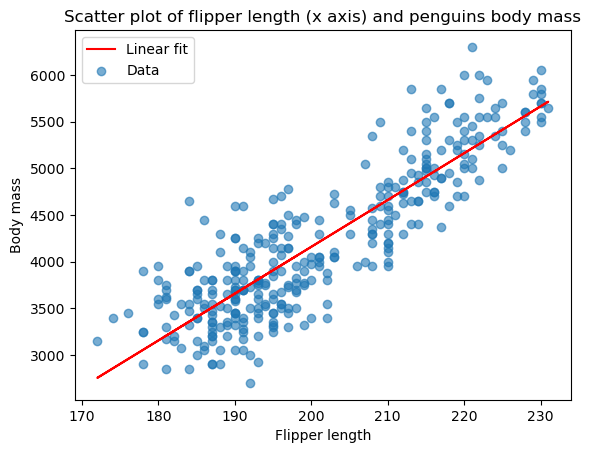

In [29]:
plt.plot(X_single, y_pred, label='Linear fit', color = 'r')
plt.scatter(X_single, y, label='Data', alpha=0.6)
plt.title("Scatter plot of flipper length (x axis) and penguins body mass")
plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.legend()
plt.show()

11 - Use your matplotlib skills to make this plot nicer.

Additional tips:
- add the `alpha=0.6` option to `plt.scatter`
- add `label='Data'` and `label='Linear fit'` to `plt.scatter` and `plt.plot`, the add `plt.legend()` just before you run `plt.show()`
- play with the colours, fonts, etc.

12 - Redo questions 5-9 using the features `X_multi`.  This is higher dimensional linear regression, but it works the exact same with scikit-learn.  Because it's higher dimensional we can't plot the whole feature space.

In [19]:
model_single = LinearRegression()
model_single.fit(X_single, y)


TypeError: scatter() missing 1 required positional argument: 'y'

13 - Compare the R-squared and MSE for both linear regression models.  
- What is the difference?
- Why is it like this?

## The End